In [1]:
# including packages
using PyPlot
using PSFModels

In [2]:
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots

# define grid

In [3]:
x = range(-2, 2, 51)
xg, yg = LU.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.92 -1.92 … -1.92 -1.92; … ; 1.92 1.92 … 1.92 1.92; 2.0 2.0 … 2.0 2.0], [-2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0; … ; -2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0])

# define lens module

In [4]:
using Jens.LensModel:NFWE as NFWE
using Jens.LensModel:ComLens as ComLens
using Jens.LensBase: lens_derivative, lens_hessian, lens_potential

In [52]:
combinelens = ComLens.CombinedLens(
    NFWE  => (Rs=2.5, alpha_Rs=1.0,e1=0.1,
     e2=0.2, xcentre=-0.2, ycentre=-0.3),
    )

Jens.LensModel.ComLens.CombinedLens{Tuple{Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}}}((Jens.LensModel.NFWE,), ((Rs = 2.5, alpha_Rs = 1.0, e1 = 0.1, e2 = 0.2, xcentre = -0.2, ycentre = -0.3),))

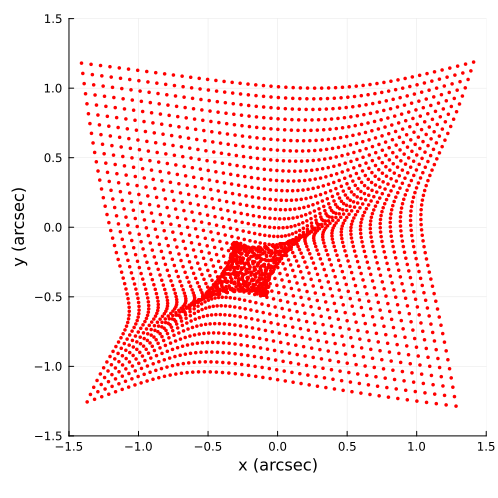

In [53]:
# lensed plane
betax, betay = LB.LensPlane(xg, yg; LensModel=combinelens)

# plot lensed plane
lensedplane = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
                    size=(500,500))
Jplots.PlotPoints!(lensedplane, betax, betay)
display(lensedplane)

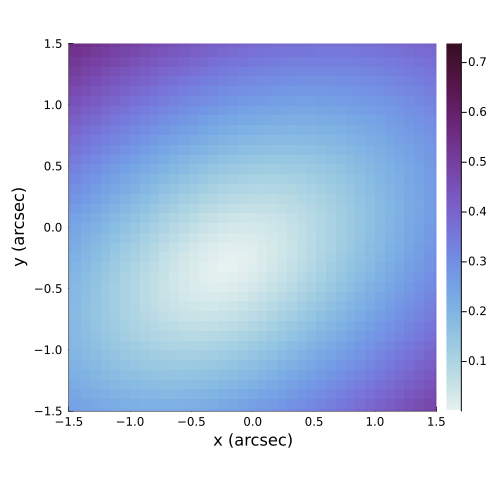

In [54]:
# Potential ψ(θ)
psi = lens_potential(combinelens, xg, yg)

potentialc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
            size=(500,500))
Jplots.PlotPlane!(potentialc, xg,yg,psi)
display(potentialc)

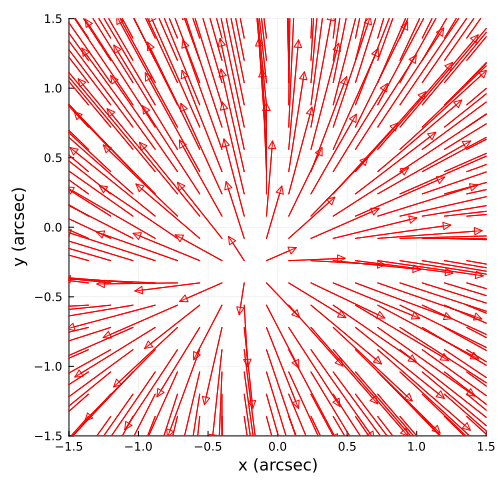

In [55]:
# deflection angle α(θ)
ax, ay = lens_derivative(combinelens, xg, yg)

deflectionc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
                size=(500,500))
Jplots.PlotVec!(deflectionc, xg, yg, ax, ay; step=2,
    color=:red, linewidth=1, arrow=Jplots.arrow(:open, 0.3))
display(deflectionc)

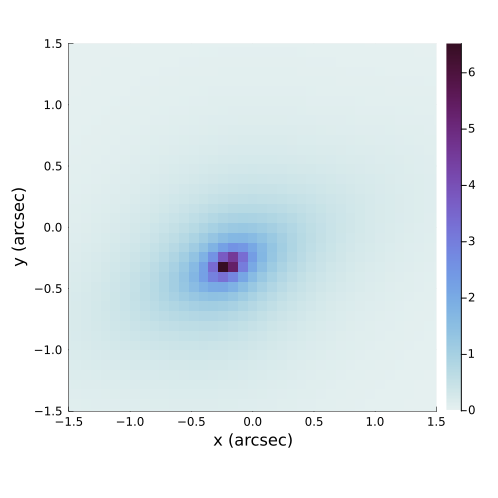

In [56]:
# Hessian f_xx, f_xy, f_yy
fxx, fxy, fyy = lens_hessian(combinelens, xg, yg)
H =  fxx .* fyy - fxy.^2
hc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
                size=(500,500))
Jplots.PlotPlane!(hc, xg, yg, H)
display(hc)

#  Lensed Image

## def Simple example

In [57]:
using Jens.LightModel:GaussianLight as GaussianLight

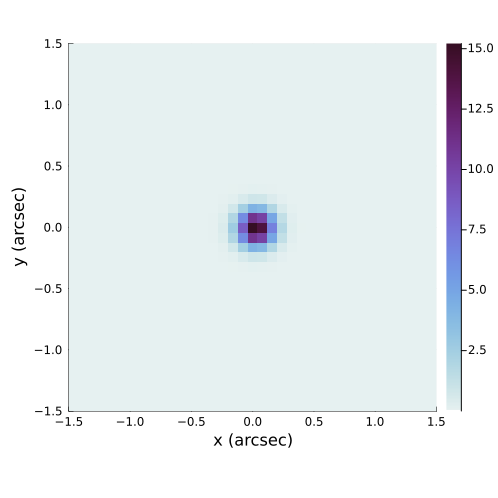

In [58]:
# source light image
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)
SourceLight = GaussianLight.GaussianSphere(xg, yg;
             LightParaDict...);
sc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
             size=(500,500))
Jplots.PlotPlane!(sc, xg, yg, SourceLight)
display(sc)

In [59]:
# lensed image
lensed = LB.LensRayShooting(xg, yg; LensModel=combinelens,
             SourceProfile=GaussianLight.GaussianSphere, 
             SourceKwargs = Dict(:amp=>1., :sigma=>0.1,
             :xcentre=>0.03, :ycentre=>0.0));

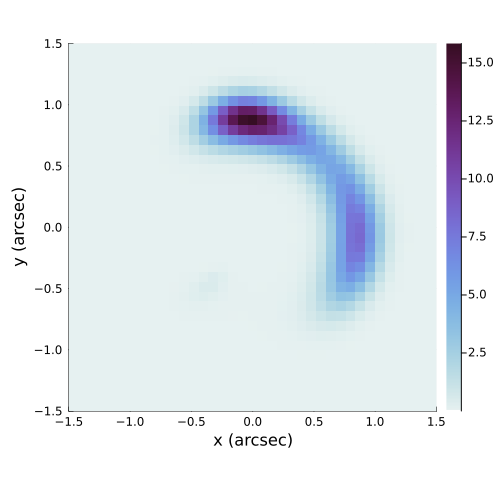

In [60]:
lc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
                size=(500,500))
Jplots.PlotPlane!(lc, xg, yg, lensed)
display(lc)

# full example

In [61]:
using Cosmology
using Jens:LightModel as LM

In [68]:
# def lens plane
cosmo = Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
lp = LG.LensedPlane(combinelens; z_lens=0.1, cosmology=cosmo)
# def source plane
## def AbstractLight model
Source = LM.ExtendedSource(
    GaussianLight.GaussianSphere; LightParaDict...)
## def LightPlane
sp = LG.LightPlane(Source, z=1)

Jens.LensGenerator.LightPlane{ExtendedSource{typeof(Jens.LightModel.GaussianLight.GaussianSphere), @NamedTuple{sigma::Float64, amp::Float64, xcentre::Float64, ycentre::Float64}}}(ExtendedSource{typeof(Jens.LightModel.GaussianLight.GaussianSphere), @NamedTuple{sigma::Float64, amp::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.GaussianLight.GaussianSphere, (sigma = 0.1, amp = 1.0, xcentre = 0.03, ycentre = 0.0)), 1.0)

In [69]:
# Ray shooting from source plane via lens plane
lensed = LB.LensRayShooting(xg, yg; LensModel=lp, SourceProfile=sp);

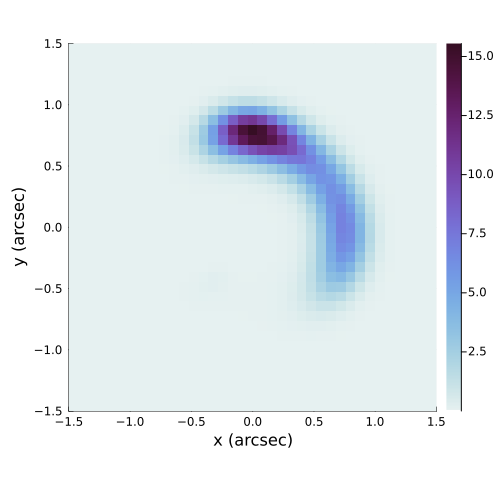

In [70]:
lc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
                size=(500,500))
Jplots.PlotPlane!(lc, xg, yg, lensed)
display(lc)